# BVCP Embedding Analysis with Voyage-4-Large

Embeds all available versions of the Boulder Valley Comprehensive Plan (1977–2026) using Voyage AI's `voyage-4-large` model, pools chunk-level embeddings for long documents, and analyzes semantic drift across nearly 50 years of comprehensive planning.

**Requirements:** `pip install voyageai numpy scipy scikit-learn matplotlib seaborn`  
**API key:** Set `VOYAGE_API_KEY` environment variable or paste below.

In [26]:
import os
import json
import time
import hashlib
import pickle
from pathlib import Path
import pandas as pd

# Fix HuggingFace cache permissions — must be set before importing voyageai.
# If ~/.cache/huggingface isn't writable, fall back to a project-local cache.
_hf_default = os.path.expanduser('~/.cache/huggingface')
try:
    os.makedirs(_hf_default, exist_ok=True)
    _test = os.path.join(_hf_default, '.write_test')
    open(_test, 'w').close(); os.remove(_test)
except (PermissionError, OSError):
    _hf_fallback = os.path.join(os.getcwd(), '.hf_cache')
    os.makedirs(_hf_fallback, exist_ok=True)
    os.environ['HF_HOME'] = _hf_fallback
    print(f'HF cache redirected to {_hf_fallback}')

import numpy as np
import voyageai
from scipy.spatial.distance import cosine, squareform, pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)

# ── API key ──────────────────────────────────────────────
# Set your Voyage API key here or via environment variable
os.environ['VOYAGE_API_KEY'] = 'pa-_EVz0kgSJO9TzpJyGUlcfxWB048-r_tJRSiWknre0-7'

vo = voyageai.Client()

HF cache redirected to /Users/briankeegan/Library/CloudStorage/Dropbox/Hacking/Boulder politics/Boulder Valley Comprehensive Plan/Analysis/.hf_cache


## 1. Document Inventory

Map short version labels to upload paths and chronological positions.

In [8]:
UPLOAD_DIR = Path('/Users/briankeegan/Library/CloudStorage/Dropbox/Hacking/Boulder politics/Boulder Valley Comprehensive Plan/Markdown')
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

# Version metadata: short_key -> (display_label, numeric_year)
FILE_VERSION_MAP = {
    'BVCP 1977 Aug.md': ('1977 (Aug)', 1977),
    'BVCP 1978.md': ('1977 Rev. 1978', 1978.0),
    'BVCP 1978 Apr.md': ('1978 (Apr)', 1978.3),
    'BVCP 1978 Jun.md': ('1978 (Jun)', 1978.5),
    'BVCP 1979 Jun.md': ('1979', 1979),
    'BVCP 1981 May.md': ('1981', 1981),
    'BVCP 1983 Oct.md': ('1983', 1983),
    'BVCP 1986 Oct.md': ('1986', 1986),
    'BVCP 1990 Dec.md': ('1990', 1990),
    'BVCP 1996 Nov.md': ('1996', 1996),
    'BVCP 2001 Sep.md': ('2001', 2001),
    'BVCP 2005 Dec.md': ('2005', 2005),
    'BVCP 2008.md': ('2008', 2008),
    'BVCP 2010.md': ('2010', 2010),
    'BVCP 2015.md': ('2015', 2015),
    'BVCP 2021 Mar.md': ('2021', 2021),
    'BVCP 2026 Mar.md': ('2026 Draft', 2026),
}

# Load available documents
documents = {}  # key -> full text
labels = []     # ordered display labels
years = []      # ordered numeric years
keys_ordered = []  # ordered short keys

for file_name, (label, year) in FILE_VERSION_MAP.items():
    if file_name is None:
        print(f'  SKIP  {label:20s} — file not in uploads')
        continue
    path = UPLOAD_DIR / file_name
    if not path.exists():
        print(f'  SKIP  {label:20s} — {file_name} not found')
        continue
    text = path.read_text(encoding='utf-8', errors='replace')
    documents[file_name] = text
    labels.append(label)
    years.append(year)
    keys_ordered.append(file_name)
    char_count = len(text)
    est_tokens = char_count // 4
    print(f'  OK    {label:20s}  {char_count:>7,} chars  (~{est_tokens:,} tokens)')

n_docs = len(documents)
print(f'\nLoaded {n_docs} of {len(FILE_VERSION_MAP)} versions')

  OK    1977 (Aug)            147,228 chars  (~36,807 tokens)
  OK    1977 Rev. 1978        261,467 chars  (~65,366 tokens)
  OK    1978 (Apr)            275,132 chars  (~68,783 tokens)
  OK    1978 (Jun)            260,825 chars  (~65,206 tokens)
  OK    1979                  293,992 chars  (~73,498 tokens)
  OK    1981                  340,662 chars  (~85,165 tokens)
  OK    1983                  360,390 chars  (~90,097 tokens)
  OK    1986                  368,107 chars  (~92,026 tokens)
  OK    1990                  367,958 chars  (~91,989 tokens)
  OK    1996                  420,657 chars  (~105,164 tokens)
  OK    2001                  479,709 chars  (~119,927 tokens)
  OK    2005                  368,028 chars  (~92,007 tokens)
  OK    2008                  389,897 chars  (~97,474 tokens)
  OK    2010                  251,097 chars  (~62,774 tokens)
  OK    2015                  380,691 chars  (~95,172 tokens)
  OK    2021                  396,758 chars  (~99,189 tokens)
  OK  

## 2. Chunking Strategy

`voyage-4-large` has a 32K-token context window and a 120K-token per-request limit. These documents range from ~37K to ~120K estimated tokens — all exceed the context window. We split on markdown headings and double-newlines into chunks of ≤16K tokens, then embed each chunk separately.

We use Voyage's built-in tokenizer (`vo.count_tokens`) for precise counts.

In [9]:
MAX_CHUNK_TOKENS = 16_000  # Conservative: half of 32K context window
MODEL = 'voyage-4-large'
EMBED_DIM = 1024  # Default dimension


def split_on_separators(text: str, separators=None) -> list[str]:
    """Split text on markdown-aware separators, preserving section structure."""
    if separators is None:
        separators = [
            '\n## ',    # H2 headings
            '\n### ',   # H3 headings
            '\n# ',     # H1 headings
            '\n\n',     # Paragraph breaks
            '\n',       # Line breaks
        ]
    # Try each separator level
    for sep in separators:
        parts = text.split(sep)
        if len(parts) > 1:
            # Re-attach separator to the start of each part (except first)
            result = [parts[0]]
            for p in parts[1:]:
                result.append(sep.lstrip('\n') + p)
            return result
    # Fallback: return as-is
    return [text]


def chunk_document(text: str, max_tokens: int = MAX_CHUNK_TOKENS) -> list[dict]:
    """
    Split a document into chunks that fit within the token limit.
    Returns list of {'text': str, 'n_tokens': int, 'chunk_idx': int}.
    Uses greedy accumulation of sections.
    """
    sections = split_on_separators(text)
    
    chunks = []
    current_text = ''
    current_tokens = 0
    
    for section in sections:
        sec_tokens = vo.count_tokens([section], model=MODEL)
        
        if current_tokens + sec_tokens > max_tokens and current_text:
            # Flush current chunk
            chunks.append({
                'text': current_text,
                'n_tokens': current_tokens,
                'chunk_idx': len(chunks),
            })
            current_text = section
            current_tokens = sec_tokens
        elif sec_tokens > max_tokens:
            # Single section exceeds limit — flush current, then split section
            if current_text:
                chunks.append({
                    'text': current_text,
                    'n_tokens': current_tokens,
                    'chunk_idx': len(chunks),
                })
            # Brute-force split by characters
            char_budget = max_tokens * 4  # rough chars-per-token
            for i in range(0, len(section), char_budget):
                sub = section[i:i + char_budget]
                sub_tokens = vo.count_tokens([sub], model=MODEL)
                chunks.append({
                    'text': sub,
                    'n_tokens': sub_tokens,
                    'chunk_idx': len(chunks),
                })
            current_text = ''
            current_tokens = 0
        else:
            current_text += ('\n\n' if current_text else '') + section
            current_tokens += sec_tokens
    
    # Final chunk
    if current_text:
        chunks.append({
            'text': current_text,
            'n_tokens': current_tokens,
            'chunk_idx': len(chunks),
        })
    
    return chunks


# Chunk all documents
all_chunks = {}  # short_key -> list of chunk dicts

for key in keys_ordered:
    label = FILE_VERSION_MAP[key][0]
    chunks = chunk_document(documents[key])
    all_chunks[key] = chunks
    total_tokens = sum(c['n_tokens'] for c in chunks)
    print(f'{label:20s}  {len(chunks):>2} chunks  {total_tokens:>7,} tokens')

total_chunks = sum(len(v) for v in all_chunks.values())
total_tokens = sum(c['n_tokens'] for v in all_chunks.values() for c in v)
print(f'\nTotal: {total_chunks} chunks, {total_tokens:,} tokens across {n_docs} documents')

tokenizer.json: 0.00B [00:00, ?B/s]

1977 (Aug)             3 chunks   29,162 tokens
1977 Rev. 1978         5 chunks   58,430 tokens
1978 (Apr)             4 chunks   61,517 tokens
1978 (Jun)             4 chunks   57,240 tokens
1979                   5 chunks   66,813 tokens
1981                   6 chunks   76,652 tokens
1983                   6 chunks   79,511 tokens
1986                   6 chunks   81,896 tokens
1990                   6 chunks   78,737 tokens
1996                   6 chunks   80,186 tokens
2001                   6 chunks   92,162 tokens
2005                   5 chunks   68,332 tokens
2008                   5 chunks   72,488 tokens
2010                   4 chunks   46,430 tokens
2015                   5 chunks   72,095 tokens
2021                   5 chunks   75,147 tokens
2026 Draft             3 chunks   33,170 tokens

Total: 84 chunks, 1,129,968 tokens across 17 documents


## 3. Embedding with Voyage-4-Large

Embed each chunk via the Voyage API with `input_type='document'` (appropriate since these are full documents, not queries). We use a cache keyed on content hash to avoid re-embedding on reruns.

Rate limiting: Voyage-4-large allows 120K tokens per request, so we send chunks individually and throttle to respect rate limits.

In [10]:
CACHE_FILE = CACHE_DIR / 'voyage4large_chunk_embeddings.pkl'


def content_hash(text: str) -> str:
    return hashlib.sha256(text.encode()).hexdigest()[:16]


def load_cache() -> dict:
    if CACHE_FILE.exists():
        with open(CACHE_FILE, 'rb') as f:
            return pickle.load(f)
    return {}


def save_cache(cache: dict):
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)


def embed_chunks_cached(chunks: list[dict], cache: dict,
                        batch_size: int = 4, delay: float = 0.5) -> list[np.ndarray]:
    """
    Embed chunks with caching. Returns list of embedding arrays.
    Batches chunks to stay well under the 120K token/request limit.
    """
    embeddings = []
    uncached_indices = []
    uncached_texts = []
    
    # Check cache
    for i, chunk in enumerate(chunks):
        h = content_hash(chunk['text'])
        if h in cache:
            embeddings.append((i, cache[h]))
        else:
            uncached_indices.append(i)
            uncached_texts.append(chunk['text'])
    
    # Embed uncached in batches
    for batch_start in range(0, len(uncached_texts), batch_size):
        batch_texts = uncached_texts[batch_start:batch_start + batch_size]
        batch_indices = uncached_indices[batch_start:batch_start + batch_size]
        
        result = vo.embed(
            batch_texts,
            model=MODEL,
            input_type='document',
        )
        
        for j, emb in enumerate(result.embeddings):
            idx = batch_indices[j]
            emb_array = np.array(emb, dtype=np.float32)
            embeddings.append((idx, emb_array))
            h = content_hash(chunks[idx]['text'])
            cache[h] = emb_array
        
        if batch_start + batch_size < len(uncached_texts):
            time.sleep(delay)
    
    # Sort by original index
    embeddings.sort(key=lambda x: x[0])
    return [e for _, e in embeddings]


# ── Run embedding ──────────────────────────────────────
cache = load_cache()
chunk_embeddings = {}  # key -> list of np.ndarray

for key in keys_ordered:
    label = FILE_VERSION_MAP[key][0]
    chunks = all_chunks[key]
    print(f'Embedding {label:20s} ({len(chunks)} chunks) ...', end=' ', flush=True)
    embs = embed_chunks_cached(chunks, cache, batch_size=2, delay=1.0)
    chunk_embeddings[key] = embs
    print(f'done ({len(embs)} embeddings, dim={embs[0].shape[0]})')
    save_cache(cache)  # Save after each document

print(f'\nCache size: {len(cache)} chunk embeddings')
print(f'Cache saved to: {CACHE_FILE}')

Embedding 1977 (Aug)           (3 chunks) ... done (3 embeddings, dim=1024)
Embedding 1977 Rev. 1978       (5 chunks) ... done (5 embeddings, dim=1024)
Embedding 1978 (Apr)           (4 chunks) ... done (4 embeddings, dim=1024)
Embedding 1978 (Jun)           (4 chunks) ... done (4 embeddings, dim=1024)
Embedding 1979                 (5 chunks) ... done (5 embeddings, dim=1024)
Embedding 1981                 (6 chunks) ... done (6 embeddings, dim=1024)
Embedding 1983                 (6 chunks) ... done (6 embeddings, dim=1024)
Embedding 1986                 (6 chunks) ... done (6 embeddings, dim=1024)
Embedding 1990                 (6 chunks) ... done (6 embeddings, dim=1024)
Embedding 1996                 (6 chunks) ... done (6 embeddings, dim=1024)
Embedding 2001                 (6 chunks) ... done (6 embeddings, dim=1024)
Embedding 2005                 (5 chunks) ... done (5 embeddings, dim=1024)
Embedding 2008                 (5 chunks) ... done (5 embeddings, dim=1024)
Embedding 20

## 4. Pooling: Chunk → Document Embeddings

For each document, we pool chunk embeddings into a single document-level vector using **token-weighted mean pooling**: each chunk's embedding is weighted by its token count, so longer chunks contribute proportionally more to the document representation. The result is L2-normalized.

We also compute an **unweighted mean** and **first-chunk-only** baseline for comparison.

In [11]:
def pool_weighted_mean(embeddings: list[np.ndarray], 
                       token_counts: list[int]) -> np.ndarray:
    """Token-weighted mean pooling with L2 normalization."""
    weights = np.array(token_counts, dtype=np.float32)
    weights /= weights.sum()
    stacked = np.stack(embeddings)
    pooled = (stacked.T @ weights)
    pooled /= np.linalg.norm(pooled)
    return pooled


def pool_unweighted_mean(embeddings: list[np.ndarray]) -> np.ndarray:
    """Simple mean pooling with L2 normalization."""
    pooled = np.mean(np.stack(embeddings), axis=0)
    pooled /= np.linalg.norm(pooled)
    return pooled


# Compute document embeddings with all pooling strategies
doc_embeddings_weighted = []   # Primary: token-weighted mean
doc_embeddings_unweighted = [] # Comparison: unweighted mean
doc_embeddings_first = []      # Comparison: first chunk only

print(f'{"Version":20s}  {"Chunks":>6s}  {"Tokens":>7s}  {"Wt-Unwt Cos":>12s}')
print('-' * 55)

for key in keys_ordered:
    label = FILE_VERSION_MAP[key][0]
    embs = chunk_embeddings[key]
    token_counts = [c['n_tokens'] for c in all_chunks[key]]
    total_tokens = sum(token_counts)
    
    wt = pool_weighted_mean(embs, token_counts)
    unwt = pool_unweighted_mean(embs)
    first = embs[0] / np.linalg.norm(embs[0])
    
    doc_embeddings_weighted.append(wt)
    doc_embeddings_unweighted.append(unwt)
    doc_embeddings_first.append(first)
    
    wt_unwt_sim = float(np.dot(wt, unwt))
    print(f'{label:20s}  {len(embs):>6}  {total_tokens:>7,}  {wt_unwt_sim:>12.4f}')

# Stack into matrices
E_wt = np.stack(doc_embeddings_weighted)     # (n_docs, 1024)
E_unwt = np.stack(doc_embeddings_unweighted)
E_first = np.stack(doc_embeddings_first)

print(f'\nDocument embedding matrix shape: {E_wt.shape}')

Version               Chunks   Tokens   Wt-Unwt Cos
-------------------------------------------------------
1977 (Aug)                 3   29,162        0.9689
1977 Rev. 1978             5   58,430        0.9919
1978 (Apr)                 4   61,517        0.9997
1978 (Jun)                 4   57,240        0.9982
1979                       5   66,813        0.9994
1981                       6   76,652        0.9958
1983                       6   79,511        0.9969
1986                       6   81,896        0.9990
1990                       6   78,737        0.9914
1996                       6   80,186        0.9932
2001                       6   92,162        0.9998
2005                       5   68,332        0.9983
2008                       5   72,488        0.9992
2010                       4   46,430        0.9832
2015                       5   72,095        0.9980
2021                       5   75,147        0.9997
2026 Draft                 3   33,170        0.9773

Documen

## 5. Cosine Similarity Matrix

Pairwise cosine similarity between all BVCP versions using the token-weighted pooled embeddings.

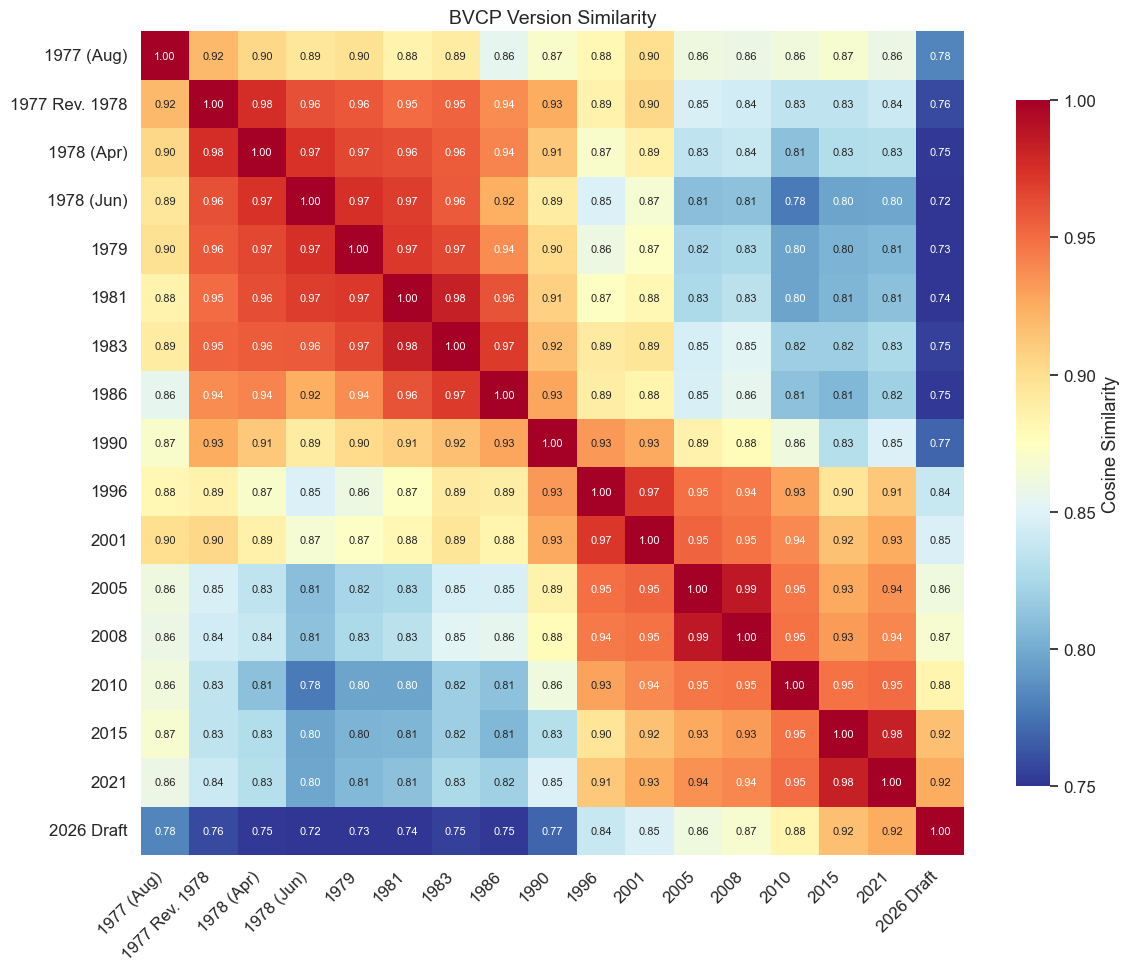

In [37]:
sim_matrix = cosine_similarity(E_wt)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(sim_matrix, dtype=bool)
# No mask — show full matrix for this use case

sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    vmin=0.75,
    vmax=1.0,
    square=True,
    ax=ax,
    cbar_kws={'label': 'Cosine Similarity', 'shrink': 0.8},
    annot_kws={'size': 8},
)
ax.set_title('BVCP Version Similarity', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bvcp_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
pd.DataFrame(sim_matrix,index=labels,columns=labels).to_clipboard()

## 6. Adjacent-Version Drift

How much does the plan change between consecutive versions? Plot cosine distance (1 − similarity) over time.

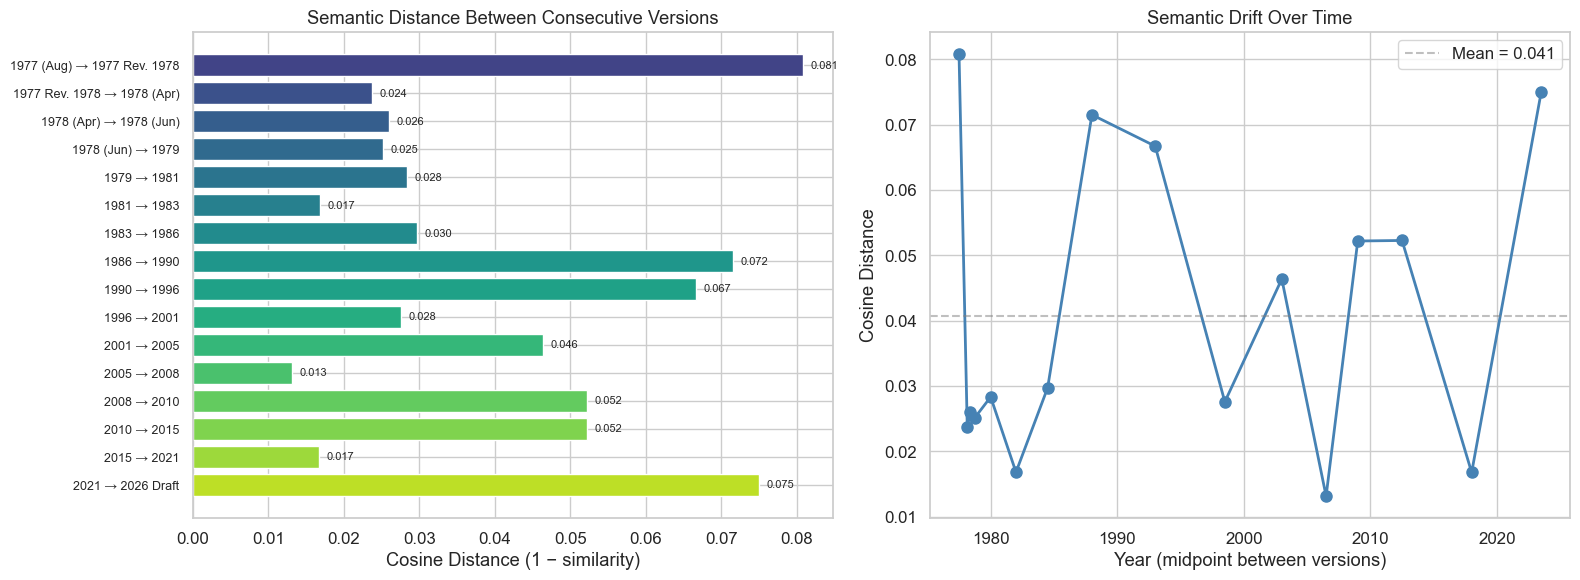

Largest semantic jumps between consecutive versions:
  0.0808  1977 (Aug) → 1977 Rev. 1978
  0.0750  2021 → 2026 Draft
  0.0715  1986 → 1990
  0.0667  1990 → 1996
  0.0523  2010 → 2015


In [13]:
# Compute adjacent-version cosine distances
adjacent_distances = []
adjacent_years_mid = []
adjacent_labels_pairs = []

for i in range(len(keys_ordered) - 1):
    sim = float(np.dot(doc_embeddings_weighted[i], doc_embeddings_weighted[i + 1]))
    dist = 1.0 - sim
    adjacent_distances.append(dist)
    adjacent_years_mid.append((years[i] + years[i + 1]) / 2)
    adjacent_labels_pairs.append(f'{labels[i]} → {labels[i+1]}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(adjacent_distances)))
bars = ax1.barh(range(len(adjacent_distances)), adjacent_distances, color=colors)
ax1.set_yticks(range(len(adjacent_distances)))
ax1.set_yticklabels(adjacent_labels_pairs, fontsize=9)
ax1.set_xlabel('Cosine Distance (1 − similarity)')
ax1.set_title('Semantic Distance Between Consecutive Versions')
ax1.invert_yaxis()

# Annotate values
for i, (bar, dist) in enumerate(zip(bars, adjacent_distances)):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{dist:.3f}', va='center', fontsize=8)

# Time series
ax2.plot(adjacent_years_mid, adjacent_distances, 'o-', color='steelblue', 
         markersize=8, linewidth=2)
ax2.set_xlabel('Year (midpoint between versions)')
ax2.set_ylabel('Cosine Distance')
ax2.set_title('Semantic Drift Over Time')
ax2.axhline(np.mean(adjacent_distances), color='gray', linestyle='--', 
            alpha=0.5, label=f'Mean = {np.mean(adjacent_distances):.3f}')
ax2.legend()

plt.tight_layout()
plt.savefig('bvcp_adjacent_drift.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the largest jumps
ranked = sorted(zip(adjacent_distances, adjacent_labels_pairs), reverse=True)
print('Largest semantic jumps between consecutive versions:')
for dist, pair in ranked[:5]:
    print(f'  {dist:.4f}  {pair}')

## 7. Drift from 1977 Baseline

How far has each version drifted from the original 1977 plan?

In [31]:
pd.Series(dict(zip(years,drift_from_baseline))).to_clipboard()

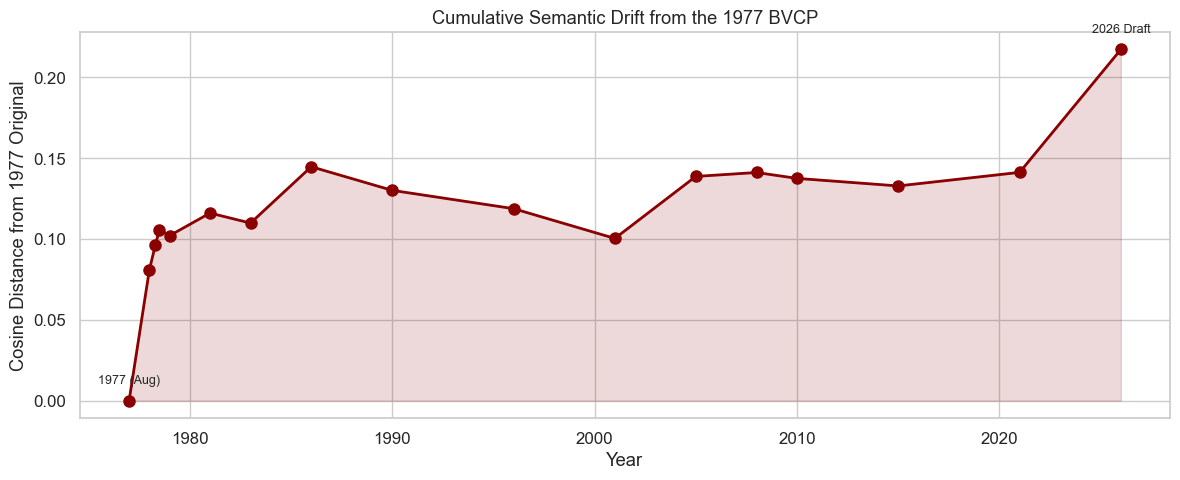

In [14]:
baseline = doc_embeddings_weighted[0]  # 1977 (Aug)

drift_from_baseline = []
for emb in doc_embeddings_weighted:
    drift_from_baseline.append(1.0 - float(np.dot(baseline, emb)))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, drift_from_baseline, 'o-', color='darkred', markersize=8, linewidth=2)
ax.fill_between(years, drift_from_baseline, alpha=0.15, color='darkred')

for i, (y, d, l) in enumerate(zip(years, drift_from_baseline, labels)):
    if i == 0 or i == len(years) - 1 or d == max(drift_from_baseline):
        ax.annotate(l, (y, d), textcoords='offset points', 
                    xytext=(0, 12), ha='center', fontsize=9)

ax.set_xlabel('Year')
ax.set_ylabel('Cosine Distance from 1977 Original')
ax.set_title('Cumulative Semantic Drift from the 1977 BVCP')
plt.tight_layout()
plt.savefig('bvcp_baseline_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Dimensionality Reduction: PCA & MDS

Project document embeddings to 2D to visualize clustering and temporal trajectory.

/opt/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_43300/4121536602.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


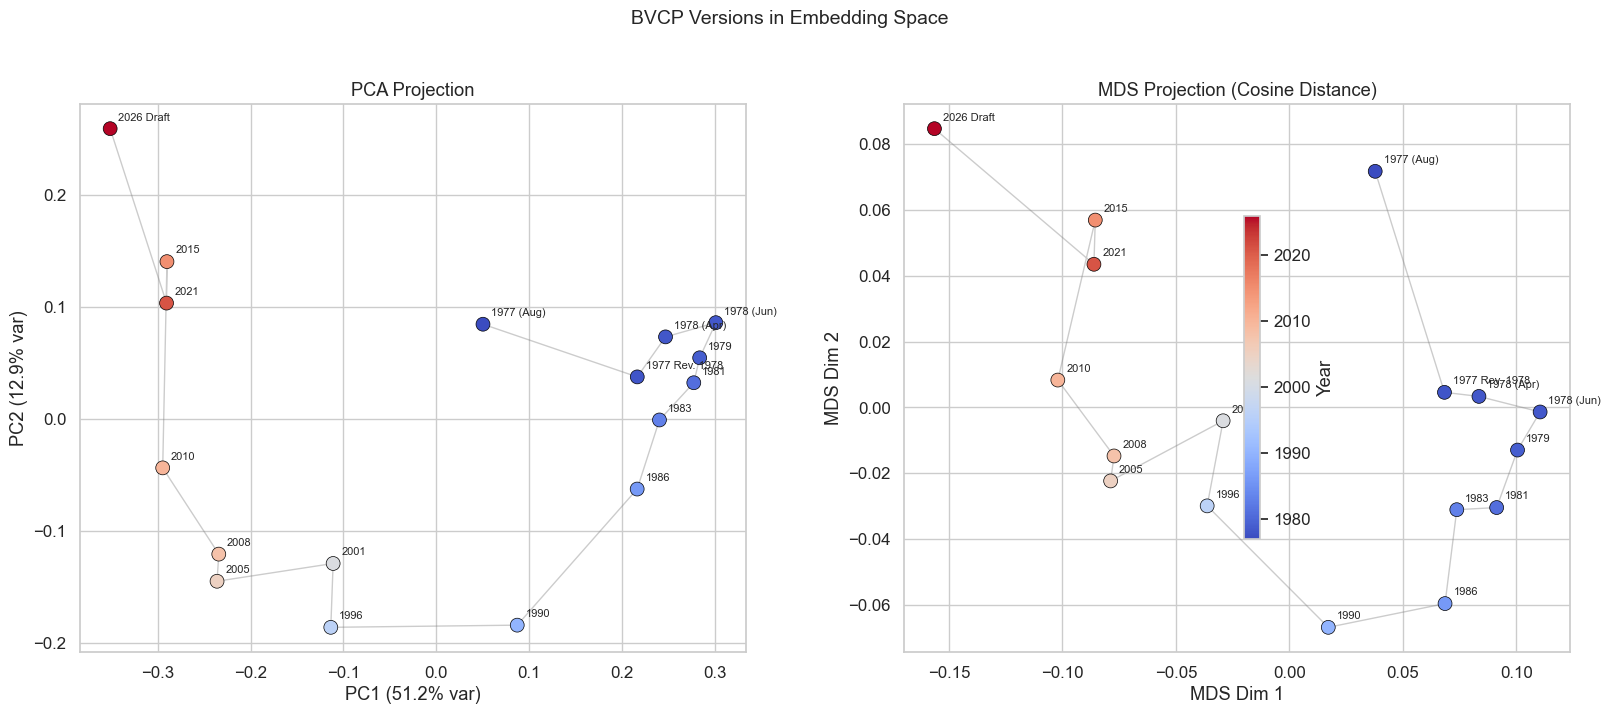

PCA explained variance: PC1=51.2%, PC2=12.9%, Total=64.2%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
year_array = np.array(years)
norm_years = (year_array - year_array.min()) / (year_array.max() - year_array.min())
colors_by_year = cm.coolwarm(norm_years)

# ── PCA ──
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(E_wt)

ax = axes[0]
ax.scatter(coords_pca[:, 0], coords_pca[:, 1], c=colors_by_year, 
           s=100, edgecolors='black', linewidth=0.5, zorder=3)
# Draw trajectory line
ax.plot(coords_pca[:, 0], coords_pca[:, 1], '-', color='gray', 
        alpha=0.4, linewidth=1, zorder=1)
for i, label in enumerate(labels):
    ax.annotate(label, (coords_pca[i, 0], coords_pca[i, 1]),
                textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PCA Projection')

# ── MDS ──
dist_matrix = 1 - sim_matrix
np.fill_diagonal(dist_matrix, 0)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_mds = mds.fit_transform(dist_matrix)

ax = axes[1]
ax.scatter(coords_mds[:, 0], coords_mds[:, 1], c=colors_by_year,
           s=100, edgecolors='black', linewidth=0.5, zorder=3)
ax.plot(coords_mds[:, 0], coords_mds[:, 1], '-', color='gray',
        alpha=0.4, linewidth=1, zorder=1)
for i, label in enumerate(labels):
    ax.annotate(label, (coords_mds[i, 0], coords_mds[i, 1]),
                textcoords='offset points', xytext=(6, 6), fontsize=8)
ax.set_xlabel('MDS Dim 1')
ax.set_ylabel('MDS Dim 2')
ax.set_title('MDS Projection (Cosine Distance)')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', 
                            norm=plt.Normalize(vmin=min(years), vmax=max(years)))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Year', shrink=0.6, pad=0.02)

fig.suptitle('BVCP Versions in Embedding Space', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bvcp_projections.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}, '
      f'Total={sum(pca.explained_variance_ratio_[:2]):.1%}')

## 9. Hierarchical Clustering

Dendrogram of BVCP versions based on cosine distance. This reveals which eras of comprehensive planning are most semantically similar to each other.

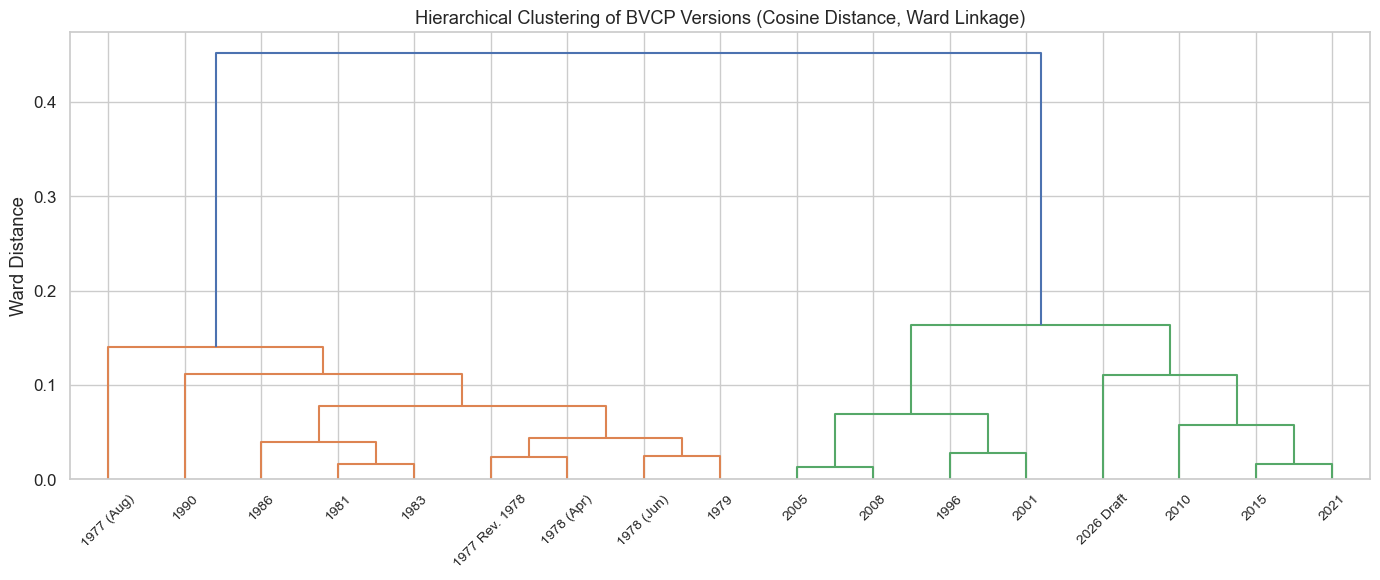

In [16]:
# Condensed distance matrix for linkage
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dn = dendrogram(
    Z,
    labels=labels,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax,
)
ax.set_ylabel('Ward Distance')
ax.set_title('Hierarchical Clustering of BVCP Versions (Cosine Distance, Ward Linkage)')
plt.tight_layout()
plt.savefig('bvcp_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Pooling Strategy Comparison

How much does pooling strategy matter? Compare the similarity matrices produced by token-weighted mean, unweighted mean, and first-chunk-only baselines.

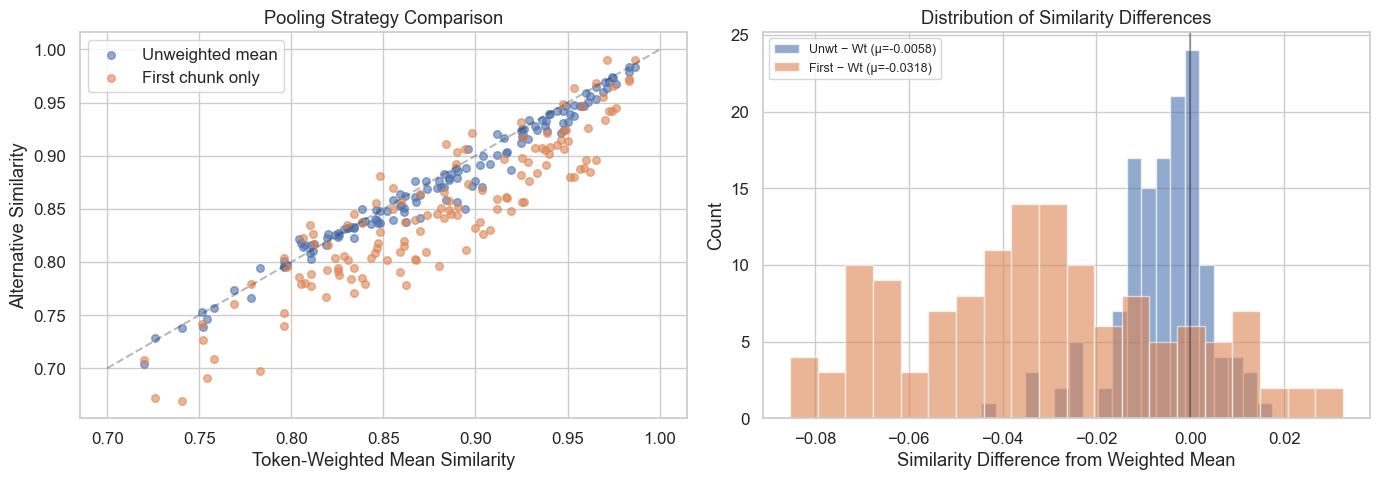

Correlation (weighted vs unweighted): 0.9882
Correlation (weighted vs first-only):  0.9111


In [17]:
sim_wt = cosine_similarity(E_wt)
sim_unwt = cosine_similarity(E_unwt)
sim_first = cosine_similarity(E_first)

# Compare upper triangles
triu_idx = np.triu_indices(n_docs, k=1)

wt_vals = sim_wt[triu_idx]
unwt_vals = sim_unwt[triu_idx]
first_vals = sim_first[triu_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(wt_vals, unwt_vals, alpha=0.6, s=30, label='Unweighted mean')
ax.scatter(wt_vals, first_vals, alpha=0.6, s=30, label='First chunk only')
ax.plot([0.7, 1], [0.7, 1], 'k--', alpha=0.3)
ax.set_xlabel('Token-Weighted Mean Similarity')
ax.set_ylabel('Alternative Similarity')
ax.set_title('Pooling Strategy Comparison')
ax.legend()

ax = axes[1]
diff_unwt = unwt_vals - wt_vals
diff_first = first_vals - wt_vals
ax.hist(diff_unwt, bins=20, alpha=0.6, label=f'Unwt − Wt (μ={diff_unwt.mean():.4f})')
ax.hist(diff_first, bins=20, alpha=0.6, label=f'First − Wt (μ={diff_first.mean():.4f})')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Similarity Difference from Weighted Mean')
ax.set_ylabel('Count')
ax.set_title('Distribution of Similarity Differences')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('bvcp_pooling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation between strategies
from numpy import corrcoef
print(f'Correlation (weighted vs unweighted): {corrcoef(wt_vals, unwt_vals)[0,1]:.4f}')
print(f'Correlation (weighted vs first-only):  {corrcoef(wt_vals, first_vals)[0,1]:.4f}')

## 11. Nearest & Farthest Neighbors

For each version, which other version is it most and least semantically similar to?

In [18]:
print(f'{"Version":20s}  {"Most Similar":20s}  {"Sim":>5s}  {"Least Similar":20s}  {"Sim":>5s}')
print('-' * 80)

for i, label in enumerate(labels):
    sims = sim_matrix[i].copy()
    sims[i] = -1  # Exclude self
    
    most_idx = np.argmax(sims)
    sims_for_min = sim_matrix[i].copy()
    sims_for_min[i] = 2  # Exclude self
    least_idx = np.argmin(sims_for_min)
    
    print(f'{label:20s}  {labels[most_idx]:20s}  {sim_matrix[i, most_idx]:.3f}  '
          f'{labels[least_idx]:20s}  {sim_matrix[i, least_idx]:.3f}')

Version               Most Similar            Sim  Least Similar           Sim
--------------------------------------------------------------------------------
1977 (Aug)            1977 Rev. 1978        0.919  2026 Draft            0.783
1977 Rev. 1978        1978 (Apr)            0.976  2026 Draft            0.758
1978 (Apr)            1977 Rev. 1978        0.976  2026 Draft            0.752
1978 (Jun)            1979                  0.975  2026 Draft            0.720
1979                  1978 (Jun)            0.975  2026 Draft            0.726
1981                  1983                  0.983  2026 Draft            0.741
1983                  1981                  0.983  2026 Draft            0.754
1986                  1983                  0.970  2026 Draft            0.751
1990                  1996                  0.933  2026 Draft            0.769
1996                  2001                  0.972  2026 Draft            0.839
2001                  1996                  0.972 

## 12. Era Analysis

Group versions into planning eras and compute within-era vs. between-era similarity.

In [19]:
# Define planning eras
def get_era(year):
    if year < 1980:
        return 'Founding (1977–79)'
    elif year < 1990:
        return 'Growth Mgmt (1981–86)'
    elif year < 2000:
        return 'Maturation (1990–96)'
    elif year < 2015:
        return 'Modern (2001–10)'
    else:
        return 'Contemporary (2015+)'

eras = [get_era(y) for y in years]
era_names = list(dict.fromkeys(eras))  # Preserve order

# Compute within-era and between-era average similarities
print(f'{"Era":25s}  {"Versions":>3s}  {"Within-Era Sim":>15s}')
print('-' * 50)

era_sims = {}
for era in era_names:
    indices = [i for i, e in enumerate(eras) if e == era]
    if len(indices) < 2:
        avg = float('nan')
    else:
        pairs = [(i, j) for i in indices for j in indices if i < j]
        avg = np.mean([sim_matrix[i, j] for i, j in pairs])
    era_sims[era] = avg
    print(f'{era:25s}  {len(indices):>3}  {avg:>15.4f}')

# Between-era average similarities
print(f'\n{"Between Eras":>25s}', end='')
for era in era_names:
    print(f'  {era[:10]:>12s}', end='')
print()

for era_a in era_names:
    print(f'{era_a:25s}', end='')
    idx_a = [i for i, e in enumerate(eras) if e == era_a]
    for era_b in era_names:
        idx_b = [i for i, e in enumerate(eras) if e == era_b]
        pairs = [(i, j) for i in idx_a for j in idx_b if i != j]
        if pairs:
            avg = np.mean([sim_matrix[i, j] for i, j in pairs])
            print(f'  {avg:>12.3f}', end='')
        else:
            print(f'  {"—":>12s}', end='')
    print()

Era                        Versions   Within-Era Sim
--------------------------------------------------
Founding (1977–79)           5           0.9425
Growth Mgmt (1981–86)        3           0.9712
Maturation (1990–96)         2           0.9333
Modern (2001–10)             4           0.9534
Contemporary (2015+)         3           0.9417

             Between Eras    Founding (    Growth Mgm    Maturation    Modern (20    Contempora
Founding (1977–79)                0.943         0.937         0.884         0.843         0.800
Growth Mgmt (1981–86)             0.937         0.971         0.901         0.845         0.793
Maturation (1990–96)              0.884         0.901         0.933         0.918         0.849
Modern (2001–10)                  0.843         0.845         0.918         0.953         0.911
Contemporary (2015+)              0.800         0.793         0.849         0.911         0.942


## 13. Chunk-Level Similarity (Intra-Document)

How internally coherent is each version? Measure the average pairwise cosine similarity among a document's own chunks.

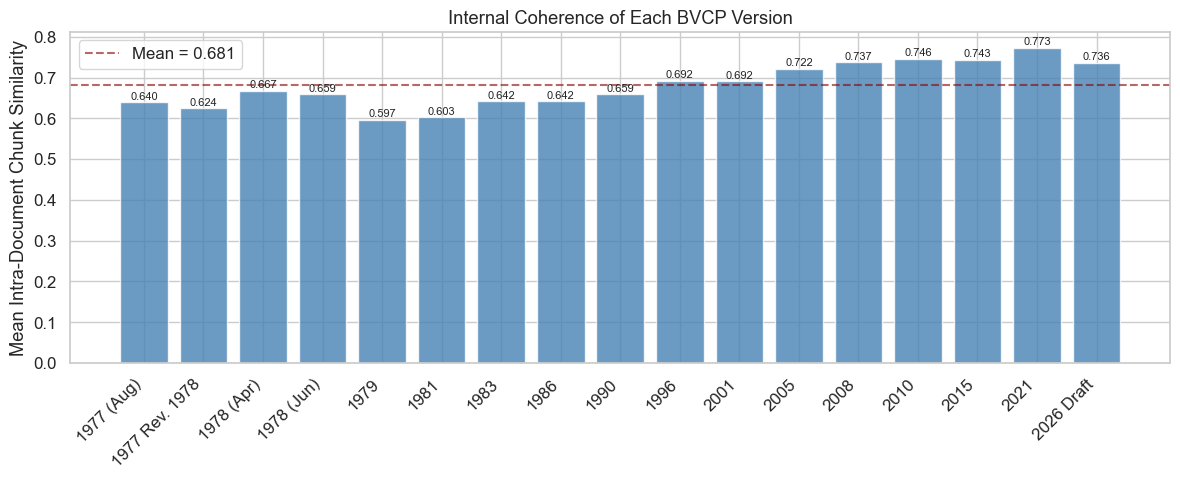

In [20]:
internal_coherence = []

for key in keys_ordered:
    embs = chunk_embeddings[key]
    if len(embs) < 2:
        internal_coherence.append(1.0)
        continue
    chunk_sim = cosine_similarity(np.stack(embs))
    triu = chunk_sim[np.triu_indices(len(embs), k=1)]
    internal_coherence.append(float(np.mean(triu)))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(n_docs), internal_coherence, color='steelblue', alpha=0.8)
ax.set_xticks(range(n_docs))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Mean Intra-Document Chunk Similarity')
ax.set_title('Internal Coherence of Each BVCP Version')
ax.axhline(np.mean(internal_coherence), color='darkred', linestyle='--', 
           alpha=0.6, label=f'Mean = {np.mean(internal_coherence):.3f}')
ax.legend()

for bar, val in zip(bars, internal_coherence):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('bvcp_internal_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Export Embeddings & Summary Statistics

In [21]:
# Save document-level embeddings
export = {
    'model': MODEL,
    'embedding_dim': EMBED_DIM,
    'pooling': 'token_weighted_mean',
    'max_chunk_tokens': MAX_CHUNK_TOKENS,
    'versions': [],
}

for i, key in enumerate(keys_ordered):
    label, year = FILE_VERSION_MAP[key]
    export['versions'].append({
        'key': key,
        'label': label,
        'year': year,
        'n_chunks': len(all_chunks[key]),
        'total_tokens': sum(c['n_tokens'] for c in all_chunks[key]),
        'internal_coherence': internal_coherence[i],
        'drift_from_1977': drift_from_baseline[i],
    })

# Save numpy arrays
np.save('bvcp_doc_embeddings_weighted.npy', E_wt)
np.save('bvcp_similarity_matrix.npy', sim_matrix)

# Save metadata
with open('bvcp_embedding_metadata.json', 'w') as f:
    json.dump(export, f, indent=2)

print('Saved:')
print('  bvcp_doc_embeddings_weighted.npy  — document embeddings matrix')
print('  bvcp_similarity_matrix.npy        — pairwise cosine similarity')
print('  bvcp_embedding_metadata.json      — version metadata & statistics')
print(f'  {CACHE_FILE}   — chunk embedding cache')

# Summary table
print(f'\n{"Version":20s}  {"Year":>6s}  {"Chunks":>6s}  {"Tokens":>7s}  '
      f'{"Coherence":>10s}  {"Drift 1977":>10s}')
print('-' * 70)
for v in export['versions']:
    print(f'{v["label"]:20s}  {v["year"]:>6.1f}  {v["n_chunks"]:>6}  {v["total_tokens"]:>7,}  '
          f'{v["internal_coherence"]:>10.4f}  {v["drift_from_1977"]:>10.4f}')

Saved:
  bvcp_doc_embeddings_weighted.npy  — document embeddings matrix
  bvcp_similarity_matrix.npy        — pairwise cosine similarity
  bvcp_embedding_metadata.json      — version metadata & statistics
  cache/voyage4large_chunk_embeddings.pkl   — chunk embedding cache

Version                 Year  Chunks   Tokens   Coherence  Drift 1977
----------------------------------------------------------------------
1977 (Aug)            1977.0       3   29,162      0.6401      0.0000
1977 Rev. 1978        1978.0       5   58,430      0.6242      0.0808
1978 (Apr)            1978.3       4   61,517      0.6673      0.0964
1978 (Jun)            1978.5       4   57,240      0.6587      0.1058
1979                  1979.0       5   66,813      0.5969      0.1020
1981                  1981.0       6   76,652      0.6026      0.1160
1983                  1983.0       6   79,511      0.6424      0.1098
1986                  1986.0       6   81,896      0.6417      0.1447
1990                  199